# Assumption checks
2026.01.09.
This notebook is for the assumption checks of the LMMs. I ran into piining and dependency issues with the latest pymer4 package involving matplotlib and seaborn. I had to create a separate notebook, with a separate environment. Fot the modeling see: Vrtraining_with_pymer4.ipynb.

## Setup

In [47]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import pingouin for chi-square test of independence
import scipy.stats as stats

In [9]:
# Define function for assumption checks and visualizations
def visual_check(model_csv, dv: str):
  """
    This function loads the previously saved model data and creates
    visual diagnostic plots for a pymer4 model.
    Change environment to vr_py before running this function.
    Args:
      model_name: string name of the saved model (e.g., "HR", "HRV_SDNN")
      dv: dependent variable name for plotting titles
  """

  # Import model data
  df = model_csv
  # Extract observed and fitted values
  observed_values = df[dv]
  fitted_values = df['fitted']

  # Calculate standardized residuals
  residuals = df['resid']
  std_resids = (residuals - np.mean(residuals)) / np.std(residuals)

  # Plot 1: Observed vs Fitted
  plt.figure(figsize=(6, 4))
  sns.regplot(x=fitted_values, y=observed_values, ci=95, scatter_kws={"s": 50, "alpha": 0.6})
  plt.xlabel("Fitted Values")
  plt.ylabel("Observed Values")
  plt.title(f"Observed vs Fitted Values ({dv})")
  sns.despine()
  plt.show()

  # Plot 2: Residuals distribution
  plt.figure(figsize=(6, 4))
  sns.histplot(residuals, kde=True)
  plt.xlabel("Residuals")
  plt.ylabel("Frequency")
  plt.title("Residuals Distribution")
  plt.axvline(0, color="k", linestyle="--", linewidth=2)
  sns.despine()
  plt.show()

  # Plot 3: Standardized residuals vs Fitted
  plt.figure(figsize=(6, 4))
  sns.scatterplot(x=fitted_values, y=std_resids)
  plt.axhline(0, color='red', linestyle='--')
  plt.axhline(2.5, color="blue", linestyle="--")
  plt.axhline(-2.5, color="blue", linestyle="--")
  plt.xlabel("Fitted values")
  plt.ylabel("Standardized Residuals")
  plt.title("Standardized Residuals vs Fitted values")
  sns.despine()
  plt.show()

## HR

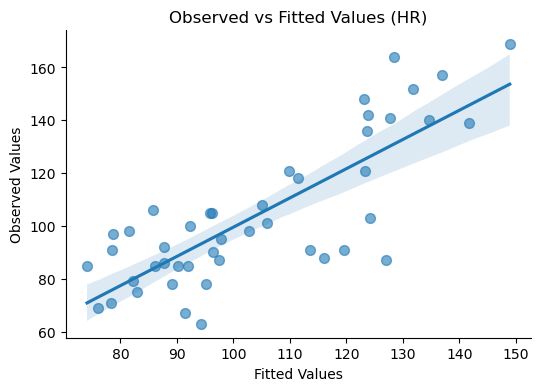

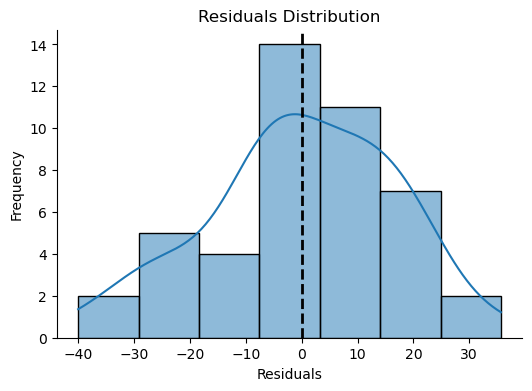

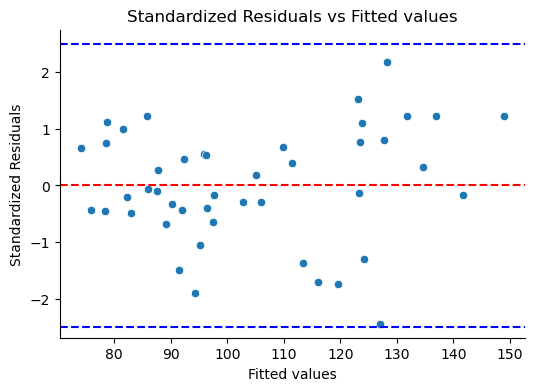

In [8]:
# Import data
df_HR = pd.read_csv("models/model_HR.csv")

# Check observed vs fitted, residuals vs frequency, residuals vs fitted plots
visual_check(df_HR, dv="HR")

## SDNN

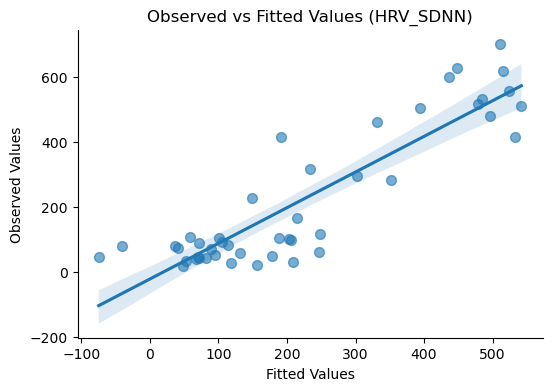

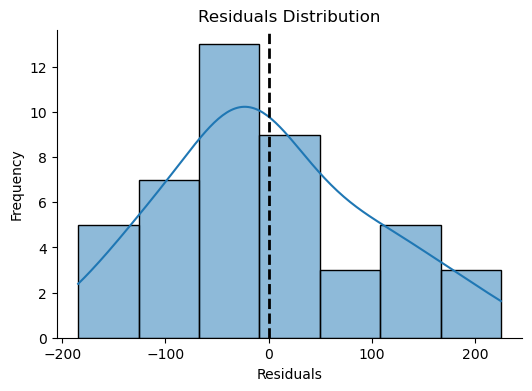

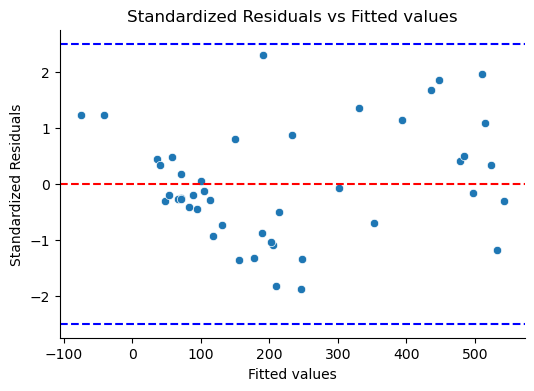

In [10]:
# Import data
df_sdnn = pd.read_csv("models/model_HRV_SDNN.csv")

# Check observed vs fitted, residuals vs frequency, residuals vs fitted plots
visual_check(df_sdnn, dv="HRV_SDNN")

## SD1/SD2

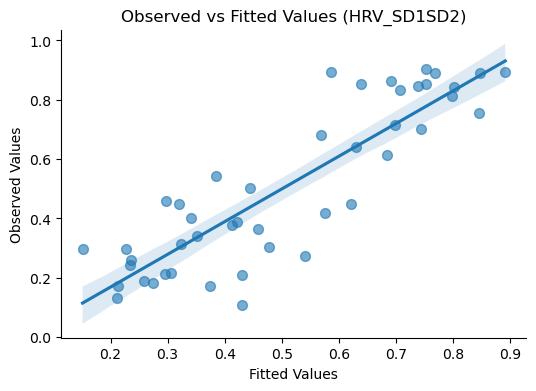

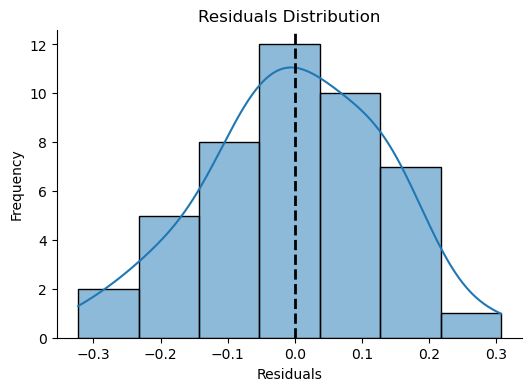

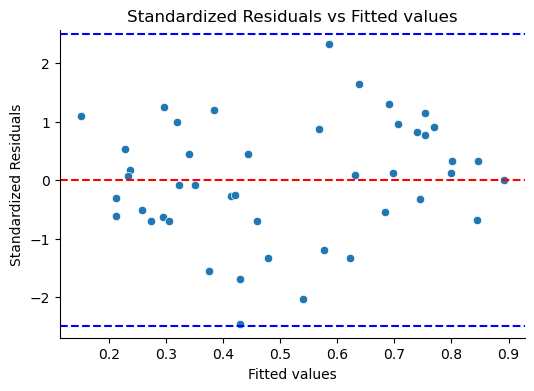

In [11]:
# Import data
df_hrv_sd1sd2 = pd.read_csv("models/model_HRV_SD1SD2.csv")

# Check observed vs fitted, residuals vs frequency, residuals vs fitted plots
visual_check(df_hrv_sd1sd2, dv="HRV_SD1SD2")

## HRV LF/HF

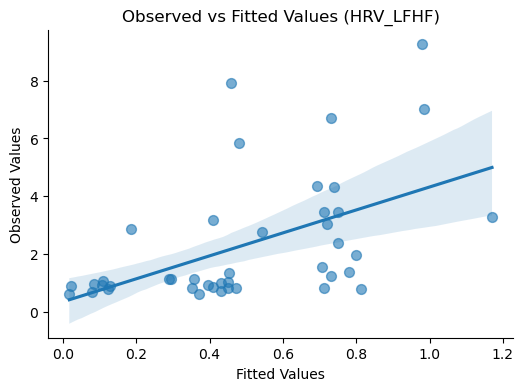

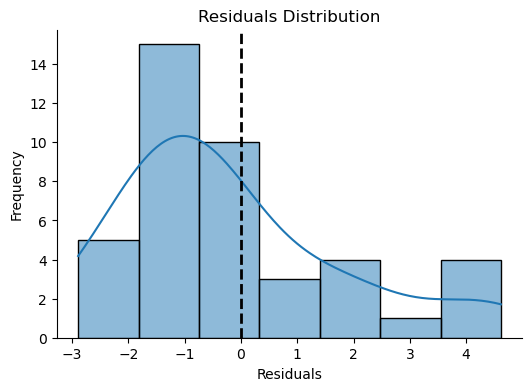

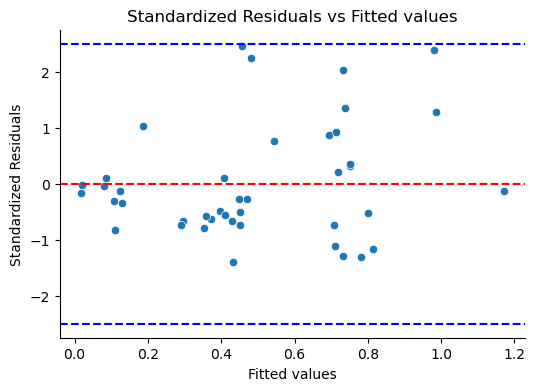

In [13]:
# Import data
df_HRV_LFHF = pd.read_csv("models/model_HRV_LFHF_log.csv")

# Check observed vs fitted, residuals vs frequency, residuals vs fitted plots
visual_check(df_HRV_LFHF, dv="HRV_LFHF")

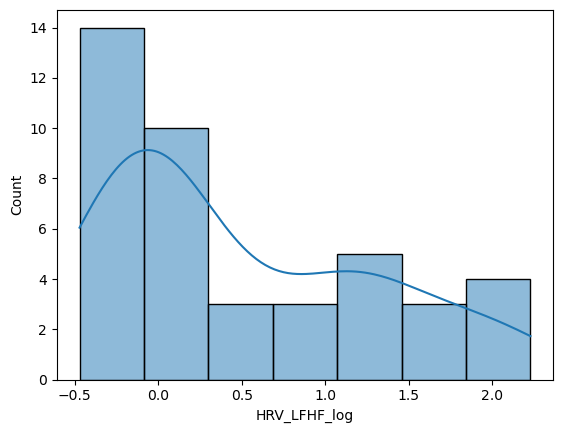

In [14]:
# dv distribution
sns.histplot(df_HRV_LFHF["HRV_LFHF_log"], kde=True)
plt.show()

## Respiratory rate

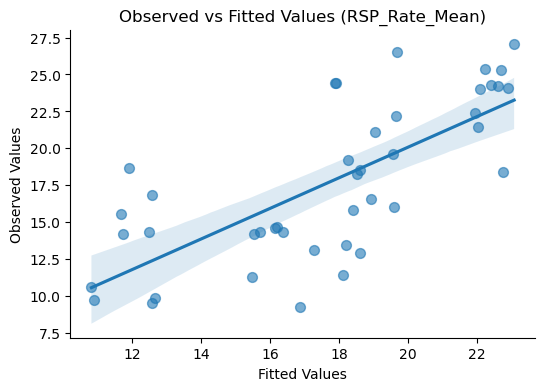

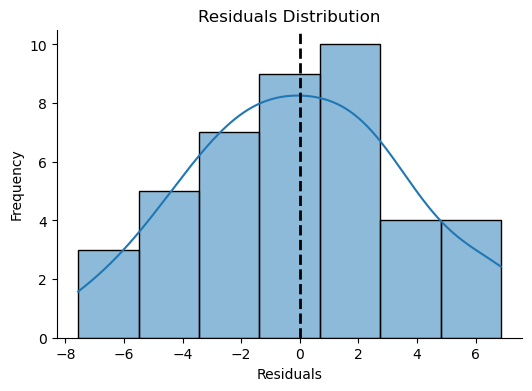

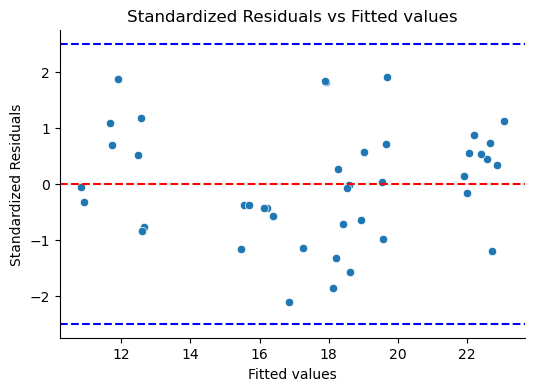

In [15]:
# Import data
df_RR = pd.read_csv("models/model_RSP_Rate_Mean.csv")


visual_check(df_RR, dv="RSP_Rate_Mean")

## SDBB

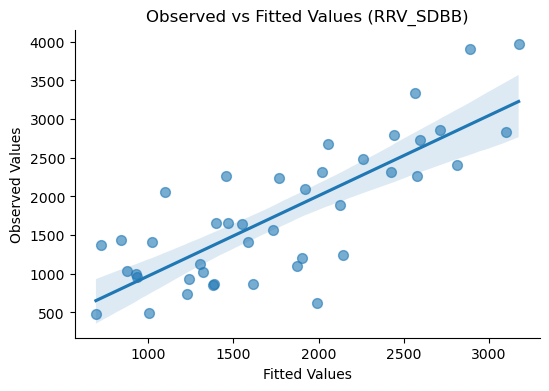

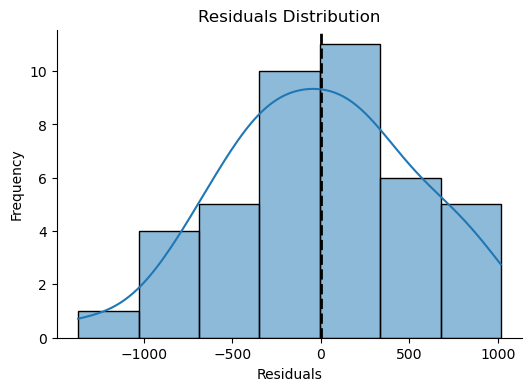

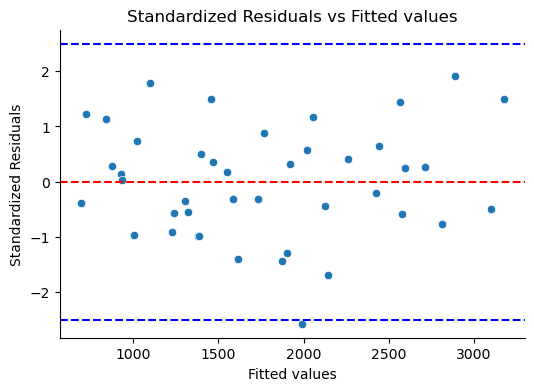

In [19]:
# Import data
df_SDBB = pd.read_csv("models/model_RRV_SDBB.csv")

visual_check(df_SDBB, "RRV_SDBB")

## RRV RMSSD

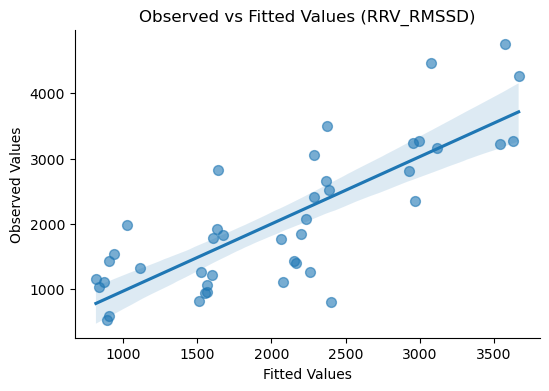

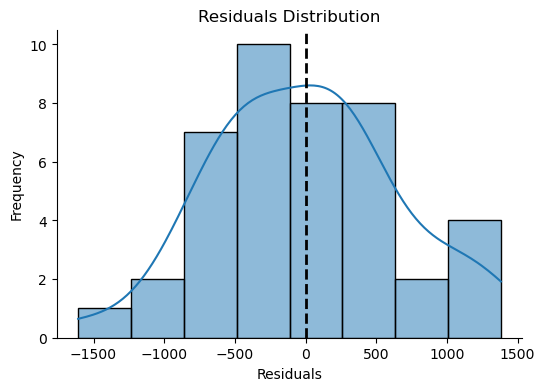

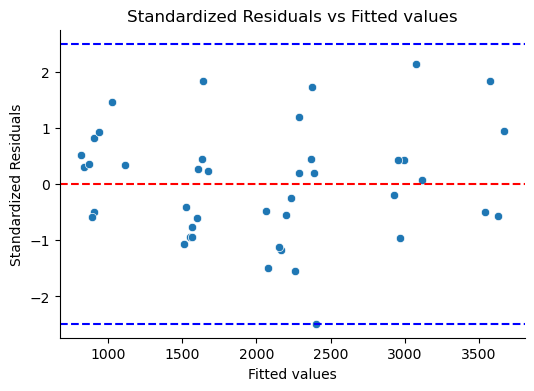

In [20]:
# Import data
df_RRV_RMSSD = pd.read_csv("models/model_RRV_RMSSD.csv")

# Visual check
visual_check(df_RRV_RMSSD, dv="RRV_RMSSD")

## RRV LF/HF

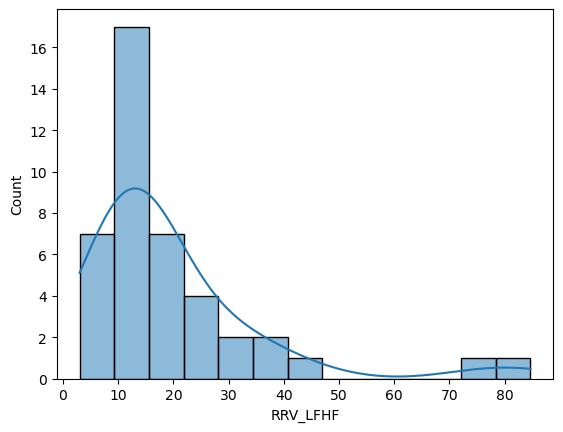

In [21]:

df_RRV_LFHF = pd.read_csv("models/model_RRV_LFHF.csv")


# dv distribution
sns.histplot(df_RRV_LFHF["RRV_LFHF"], kde=True)
plt.show()

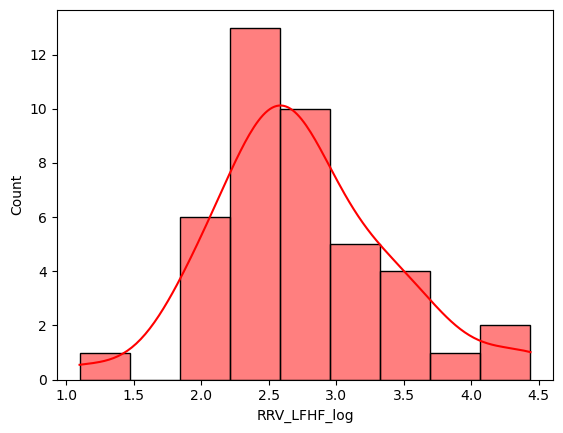

In [24]:
# Check transformed DV's distribution (transformed in previous notebook)
sns.histplot(df_RRV_LFHF["RRV_LFHF_log"], kde=True, color="red")
plt.show()

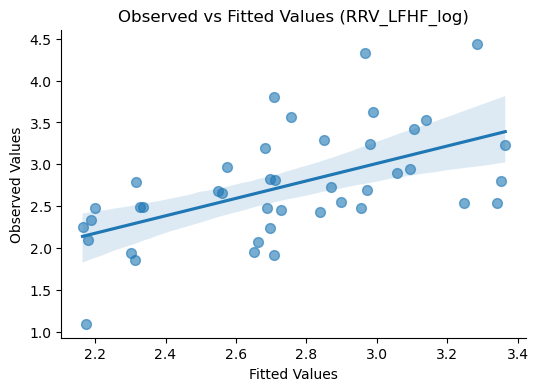

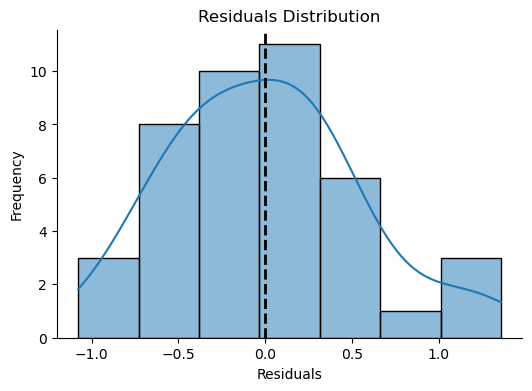

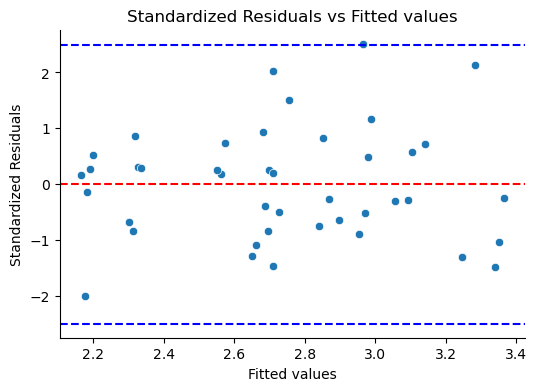

In [25]:
visual_check(df_RRV_LFHF, dv="RRV_LFHF_log")

## Testing for gender and age biases

- gender: male = 1, female = 2
- group: experimental = 1, control = 2
- instrument_type: breath control = 1, non-breath control = 2

In [13]:
# Import demographic data
demo_dat = pd.read_csv("data/demo_dat.csv", sep=";")
demo_dat

,ID,age,gender,music_training,group,instrument_type
0,vrt_06,23,2,18,1,1
1,vrt_07,20,2,16,1,1
2,vrt_02,21,1,15,1,2
3,vrt_08,23,2,16,2,1
4,vrt_05,23,2,15,2,2
5,vrt_03,19,1,14,1,2
6,vrt_10,19,1,12,2,1
7,vrt_11,19,1,12,2,2
8,vrt_12,20,2,7,1,2
9,vrt_14,21,1,14,1,1


In [45]:
# Count values in groups
gender_per_group = demo_dat.groupby(["gender", "group"]).size().unstack(fill_value=0)
gender_per_group

group,1,2
gender,,
1,3,2
2,6,4


In [50]:
# Due to the low number of observations in each group combinations (gender vs group),
# three groups have N <= 5: Fisher's Exact Test is used instead of Chi-square test
odds_ratio, p_value = stats.fisher_exact(gender_per_group)

# Print the results
print(f"Odds Ratio: {odds_ratio}, P-value: {p_value}")

Odds Ratio: 1.0, P-value: 1.0


In [52]:
# Compare age between groups
# Because the sample size is small, we will use a non-parametric test (Mann-Whitney U-test)
age_group1 = demo_dat[demo_dat['group'] == 1]['age']
age_group2 = demo_dat[demo_dat['group'] == 2]['age']

u_stat, p_value = stats.mannwhitneyu(age_group1, age_group2)
print(f"Mann-Whitney U Test: U={u_stat}, p-value={p_value}")

Mann-Whitney U Test: U=27.0, p-value=1.0
